# Projeto: Consumo de Café e Qualidade do Sono (Health&Life Analytics)
## Parte #1: Análise Exploratória de Dados (EDA)

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.2f}')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 10

### 1.1 Carregamento dos Dados

In [ ]:
data_path = 'data/synthetic_coffee_health_10000.csv'
if not os.path.exists(data_path):
    data_path = '../data/synthetic_coffee_health_10000.csv'


df = pd.read_csv(data_path, keep_default_na=False)
df.head()

,ID,Age,Gender,Country,Coffee_Intake,Caffeine_mg,Sleep_Hours,Sleep_Quality,BMI,Heart_Rate,Stress_Level,Physical_Activity_Hours,Health_Issues,Occupation,Smoking,Alcohol_Consumption
0,1,40,Male,Germany,3.50,328.10,7.50,Good,24.90,78,Low,14.50,None,Other,0,0
1,2,33,Male,Germany,1.00,94.10,6.20,Good,20.00,67,Low,11.00,None,Service,0,0
2,3,42,Male,Brazil,5.30,503.70,5.90,Fair,22.70,59,Medium,11.20,Mild,Office,0,0
3,4,53,Male,Germany,2.60,249.20,7.30,Good,24.70,71,Low,6.60,Mild,Other,0,0
4,5,32,Female,Spain,3.10,298.00,5.30,Fair,24.10,76,Medium,8.50,Mild,Student,0,1


### 1.2 Auditoria Estrutural: Dimensões, Tipos, Nulos e Duplicados

In [25]:
print(f"Dimensões do dataset: {df.shape[0]} linhas x {df.shape[1]} colunas")

df.info()
print(f"\nRegistros duplicados: {df.duplicated().sum()}")

resumo_qualidade = pd.DataFrame({
    'Tipo': df.dtypes,
    'Nulos': df.isnull().sum(),
    'Nulo_%': (df.isnull().sum() / len(df)) * 100,
    'Valores_Unicos': df.nunique()
})

Dimensões do dataset: 10000 linhas x 16 colunas
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       10000 non-null  int64  
 1   Age                      10000 non-null  int64  
 2   Gender                   10000 non-null  str    
 3   Country                  10000 non-null  str    
 4   Coffee_Intake            10000 non-null  float64
 5   Caffeine_mg              10000 non-null  float64
 6   Sleep_Hours              10000 non-null  float64
 7   Sleep_Quality            10000 non-null  str    
 8   BMI                      10000 non-null  float64
 9   Heart_Rate               10000 non-null  int64  
 10  Stress_Level             10000 non-null  str    
 11  Physical_Activity_Hours  10000 non-null  float64
 12  Health_Issues            10000 non-null  str    
 13  Occupation               10000 non-null 

### 1.3 Estatísticas Descritivas Iniciais

In [ ]:
colunas_numericas = [
    'Age', 'Coffee_Intake', 'Caffeine_mg', 'Sleep_Hours', 
    'BMI', 'Heart_Rate', 'Physical_Activity_Hours', 'Smoking', 'Alcohol_Consumption'
]

estatisticas = df[colunas_numericas].describe().T[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']]
estatisticas['IQR'] = estatisticas['75%'] - estatisticas['25%']
display(estatisticas)

,count,mean,std,min,25%,50%,75%,max,IQR
Age,10000.00,34.95,11.16,18.00,26.00,34.00,43.00,80.00,17.00
Coffee_Intake,10000.00,2.51,1.45,0.00,1.50,2.50,3.50,8.20,2.00
Caffeine_mg,10000.00,238.41,137.75,0.00,138.75,235.40,332.02,780.30,193.27
Sleep_Hours,10000.00,6.64,1.22,3.00,5.80,6.60,7.50,10.00,1.70
BMI,10000.00,23.99,3.91,15.00,21.30,24.00,26.60,38.20,5.30
Heart_Rate,10000.00,70.62,9.82,50.00,64.00,71.00,77.00,109.00,13.00
Physical_Activity_Hours,10000.00,7.49,4.32,0.00,3.70,7.50,11.20,15.00,7.50
Smoking,10000.00,0.20,0.40,0.00,0.00,0.00,0.00,1.00,0.00
Alcohol_Consumption,10000.00,0.30,0.46,0.00,0.00,0.00,1.00,1.00,1.00


### 1.4 Distribuição das Variáveis Numéricas (Histogramas e Boxplots)

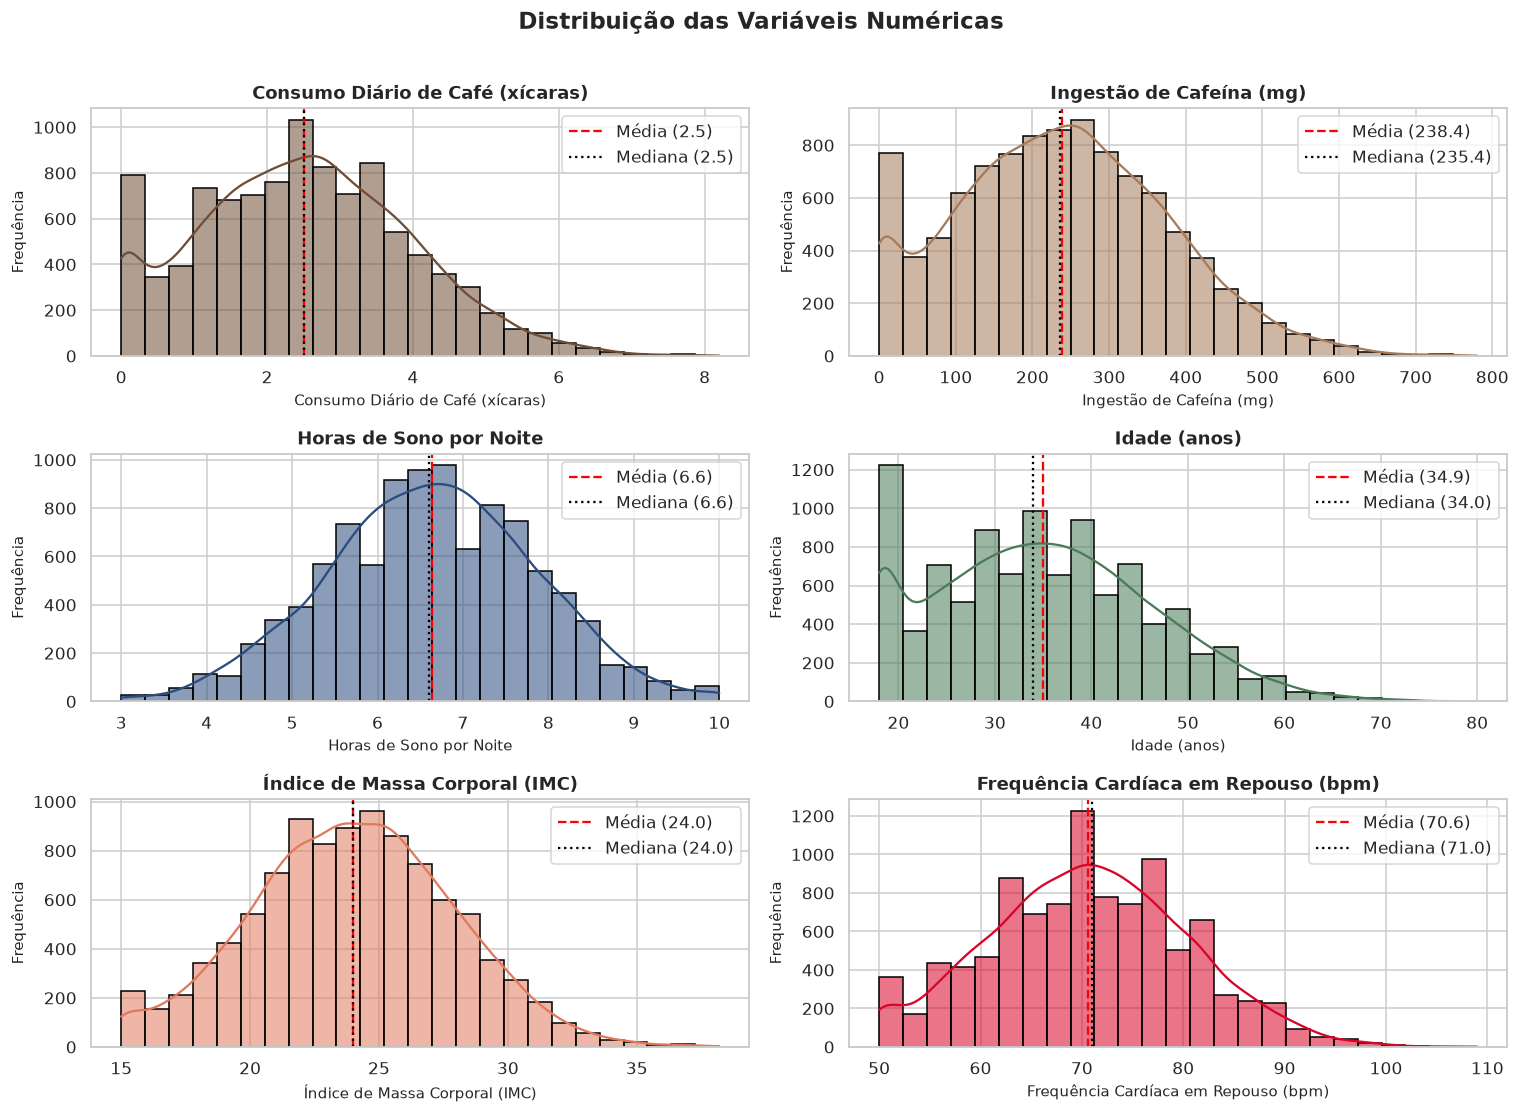

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
fig.suptitle('Distribuição das Variáveis Numéricas', fontsize=15, fontweight='bold', y=1.01)

variaveis_hist = [
    ('Coffee_Intake', 'Consumo Diário de Café (xícaras)', '#6F4E37'),
    ('Caffeine_mg', 'Ingestão de Cafeína (mg)', '#A67B5B'),
    ('Sleep_Hours', 'Horas de Sono por Noite', '#2B4C7E'),
    ('Age', 'Idade (anos)', '#4A7C59'),
    ('BMI', 'Índice de Massa Corporal (IMC)', '#E07A5F'),
    ('Heart_Rate', 'Frequência Cardíaca em Repouso (bpm)', '#D90429')
]

for ax, (col, label, color) in zip(axes.flatten(), variaveis_hist):
    sns.histplot(df[col], kde=True, ax=ax, color=color, edgecolor='black', alpha=0.55, bins=25)
    media = df[col].mean()
    mediana = df[col].median()
    ax.axvline(media, color='red', linestyle='--', linewidth=1.5, label=f'Média ({media:.1f})')
    ax.axvline(mediana, color='black', linestyle=':', linewidth=1.5, label=f'Mediana ({mediana:.1f})')
    ax.set_title(label)
    ax.set_xlabel(label)
    ax.set_ylabel('Frequência')
    ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

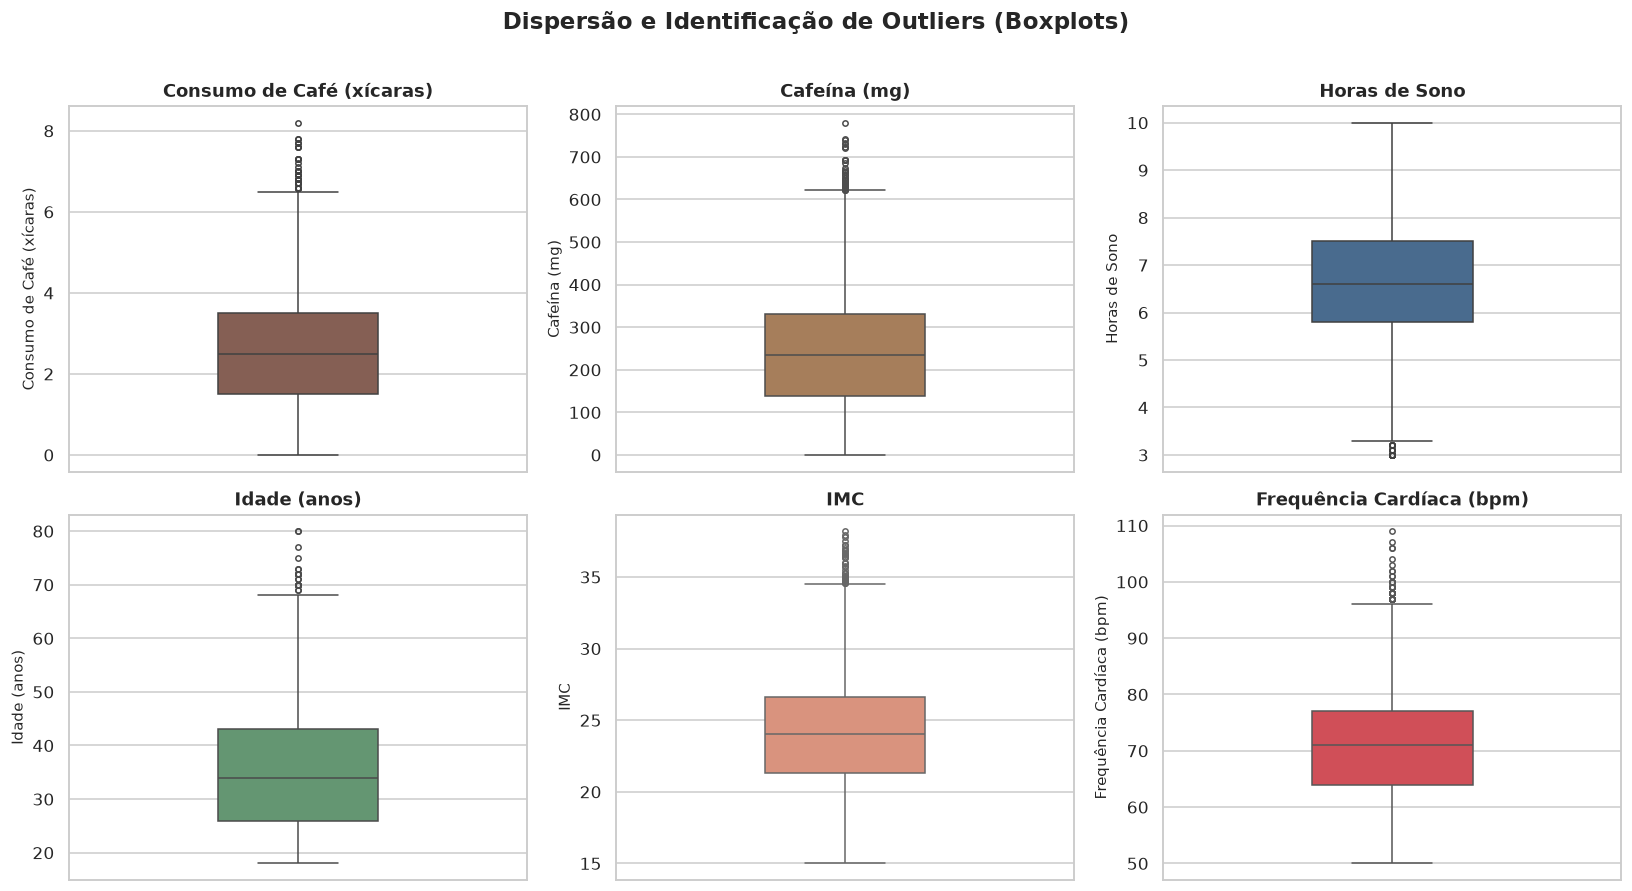

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Dispersão e Identificação de Outliers (Boxplots)', fontsize=15, fontweight='bold', y=1.01)

variaveis_box = [
    ('Coffee_Intake', 'Consumo de Café (xícaras)', '#8D5B4C'),
    ('Caffeine_mg', 'Cafeína (mg)', '#B37D4E'),
    ('Sleep_Hours', 'Horas de Sono', '#3D6B99'),
    ('Age', 'Idade (anos)', '#5C9E6E'),
    ('BMI', 'IMC', '#E88B6F'),
    ('Heart_Rate', 'Frequência Cardíaca (bpm)', '#E63946')
]

for ax, (col, label, color) in zip(axes.flatten(), variaveis_box):
    sns.boxplot(y=df[col], ax=ax, color=color, width=0.35, fliersize=3.5)
    ax.set_title(label)
    ax.set_ylabel(label)


plt.tight_layout()
plt.show()

### 1.5 Frequência das Variáveis Categóricas (Barras e Proporções)

/tmp/ipykernel_9614/2433284633.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Sleep_Quality', data=df, order=ordem_sono, ax=axes[0, 0], palette=paleta_sono)
/tmp/ipykernel_9614/2433284633.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Stress_Level', data=df, order=ordem_estresse, ax=axes[0, 1], palette=paleta_estresse)
/tmp/ipykernel_9614/2433284633.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Health_Issues', data=df, order=ordem_saude, ax=axes[1, 0], palette='Blues_r')
/tmp/ipykernel_9614/2433284633.py:50: 

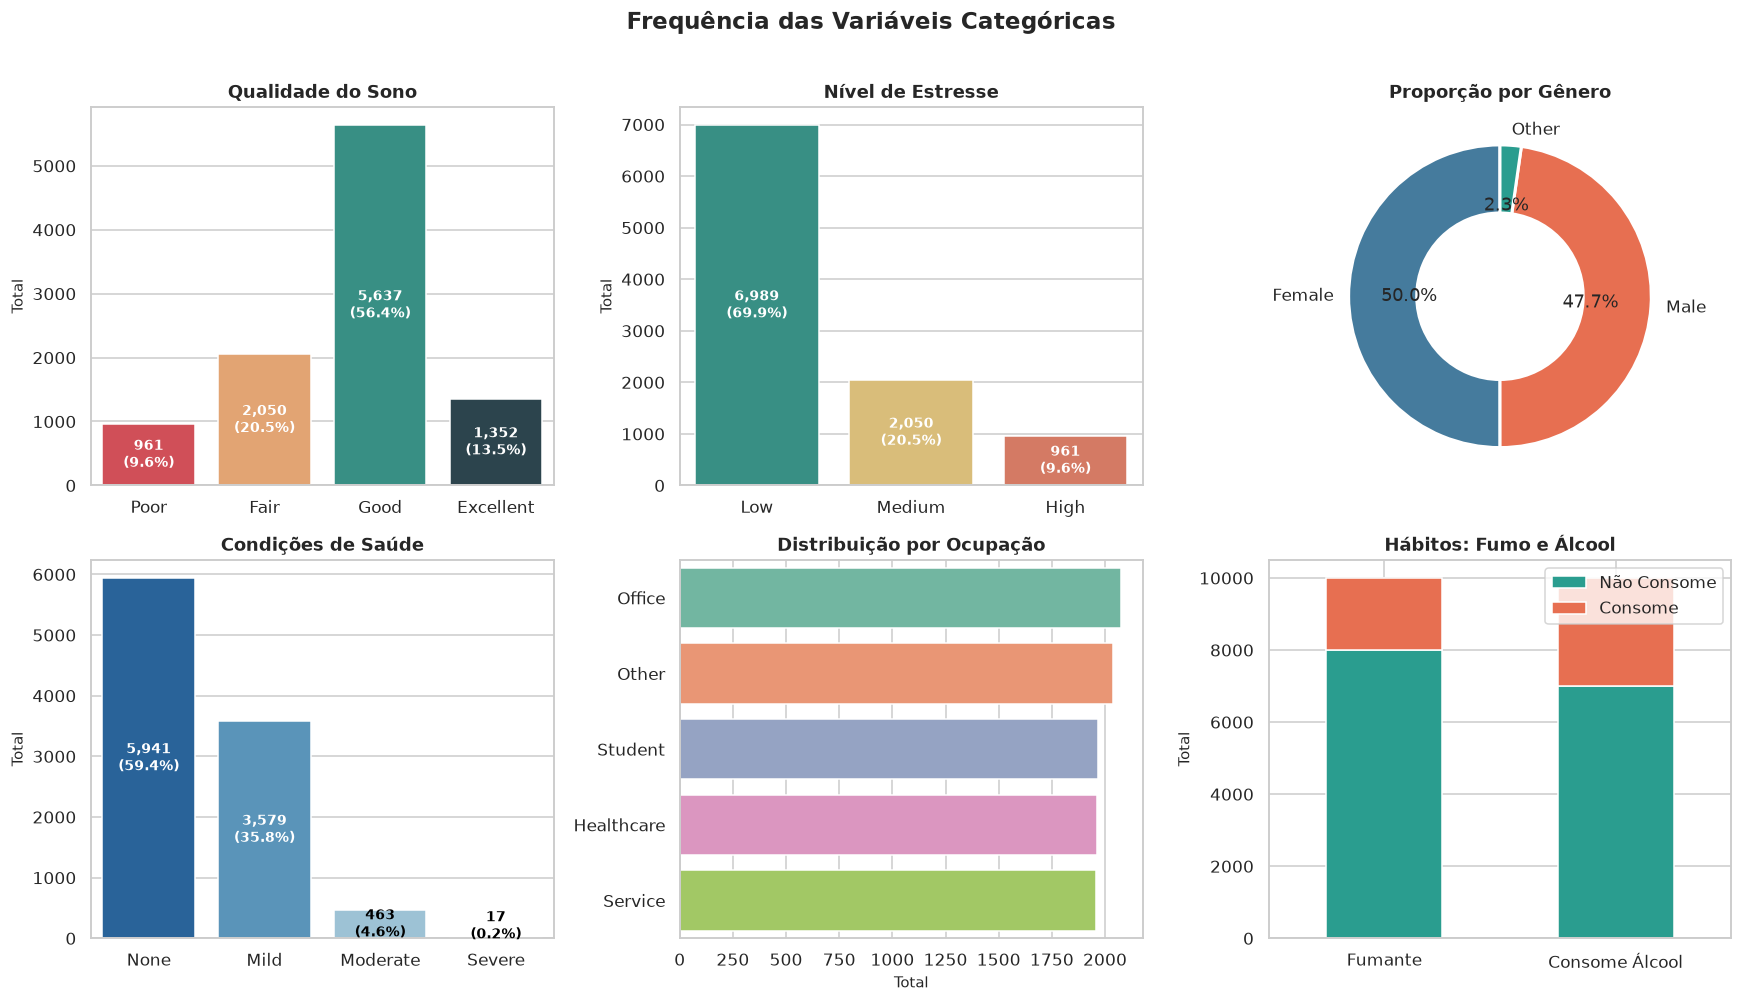

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Frequência das Variáveis Categóricas', fontsize=15, fontweight='bold', y=1.01)

ordem_sono = ['Poor', 'Fair', 'Good', 'Excellent']
paleta_sono = {'Poor': '#E63946', 'Fair': '#F4A261', 'Good': '#2A9D8F', 'Excellent': '#264653'}
sns.countplot(x='Sleep_Quality', data=df, order=ordem_sono, ax=axes[0, 0], palette=paleta_sono)
axes[0, 0].set_title('Qualidade do Sono')
axes[0, 0].set_xlabel('')
axes[0, 0].set_ylabel('Total')
for p in axes[0, 0].patches:
    axes[0, 0].annotate(f'{int(p.get_height()):,}\n({p.get_height()/len(df):.1%})',
                        (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                        ha='center', va='center', color='white', fontweight='bold', fontsize=9)


ordem_estresse = ['Low', 'Medium', 'High']
paleta_estresse = {'Low': '#2A9D8F', 'Medium': '#E9C46A', 'High': '#E76F51'}
sns.countplot(x='Stress_Level', data=df, order=ordem_estresse, ax=axes[0, 1], palette=paleta_estresse)
axes[0, 1].set_title('Nível de Estresse')
axes[0, 1].set_xlabel('')
axes[0, 1].set_ylabel('Total')
for p in axes[0, 1].patches:
    axes[0, 1].annotate(f'{int(p.get_height()):,}\n({p.get_height()/len(df):.1%})',
                        (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                        ha='center', va='center', color='white', fontweight='bold', fontsize=9)


contagem_genero = df['Gender'].value_counts()
axes[0, 2].pie(contagem_genero, labels=contagem_genero.index, autopct='%1.1f%%',
               colors=['#457B9D', '#E76F51', '#2A9D8F'], startangle=90,
               wedgeprops=dict(width=0.45, edgecolor='white', linewidth=2))
axes[0, 2].set_title('Proporção por Gênero')



ordem_saude = ['None', 'Mild', 'Moderate', 'Severe']
sns.countplot(x='Health_Issues', data=df, order=ordem_saude, ax=axes[1, 0], palette='Blues_r')
axes[1, 0].set_title('Condições de Saúde')
axes[1, 0].set_xlabel('')
axes[1, 0].set_ylabel('Total')
for p in axes[1, 0].patches:
    h = p.get_height()
    if h > 0:
        axes[1, 0].annotate(f'{int(h):,}\n({h/len(df):.1%})',
                            (p.get_x() + p.get_width() / 2., max(h / 2, 200)),
                            ha='center', va='center', color='white' if h > 1000 else 'black',
                            fontweight='bold', fontsize=9)



sns.countplot(y='Occupation', data=df, ax=axes[1, 1], palette='Set2',
              order=df['Occupation'].value_counts().index)
axes[1, 1].set_title('Distribuição por Ocupação')
axes[1, 1].set_xlabel('Total')
axes[1, 1].set_ylabel('')



df_habitos = pd.DataFrame({
    'Não Consome': [(df['Smoking'] == 0).sum(), (df['Alcohol_Consumption'] == 0).sum()],
    'Consome': [(df['Smoking'] == 1).sum(), (df['Alcohol_Consumption'] == 1).sum()]
}, index=['Fumante', 'Consome Álcool'])
df_habitos.plot(kind='bar', stacked=True, ax=axes[1, 2], color=['#2A9D8F', '#E76F51'], edgecolor='white')
axes[1, 2].set_title('Hábitos: Fumo e Álcool')
axes[1, 2].set_ylabel('Total')
axes[1, 2].legend(loc='upper right')
axes[1, 2].tick_params(axis='x', rotation=0)



plt.tight_layout();
plt.show();

### 1.6 Análise de Correlações Numéricas (Heatmap)

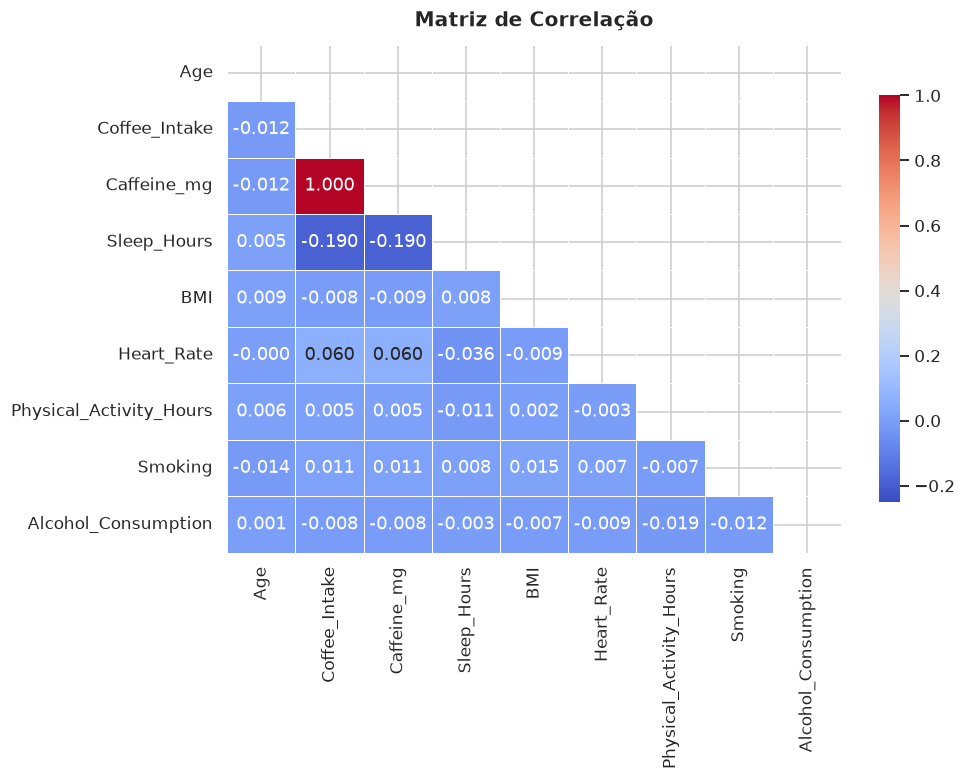

Correlações com Horas de Sono (Sleep_Hours):
Caffeine_mg               -0.19
Coffee_Intake             -0.19
Heart_Rate                -0.04
Physical_Activity_Hours   -0.01
Alcohol_Consumption       -0.00
Age                        0.01
Smoking                    0.01
BMI                        0.01
Sleep_Hours                1.00
Name: Sleep_Hours, dtype: float64


In [ ]:
matriz_corr = df[colunas_numericas].corr()


plt.figure(figsize=(9, 6))
mascara = np.triu(np.ones_like(matriz_corr, dtype=bool))
sns.heatmap(matriz_corr, mask=mascara, annot=True, fmt='.3f', cmap='coolwarm',
            vmin=-0.25, vmax=1.0, cbar_kws={'shrink': 0.8}, linewidths=0.5)
plt.title('Matriz de Correlação', fontsize=13, fontweight='bold', pad=12)
plt.show()


print("Correlações com Horas de Sono (Sleep_Hours):")
print(matriz_corr['Sleep_Hours'].sort_values())

### 1.7 Cruzamento Inicial: Consumo de Café, Sono e Estresse

In [24]:
resumo_sono = df.groupby('Sleep_Quality')[['Sleep_Hours', 'Coffee_Intake', 'Caffeine_mg']].agg(['mean', 'median', 'std'])
display(resumo_sono.loc[['Poor', 'Fair', 'Good', 'Excellent']])

tabela_cruzada_estresse = pd.crosstab(df['Stress_Level'], df['Sleep_Quality'], normalize='index') * 100
display(tabela_cruzada_estresse[['Poor', 'Fair', 'Good', 'Excellent']].loc[['High', 'Medium', 'Low']])

Sleep_Hours             Coffee_Intake             Caffeine_mg  \
                     mean median  std          mean median  std        mean   
Sleep_Quality                                                                 
Poor                 4.45   4.60 0.46          2.98   3.00 1.49      283.04   
Fair                 5.58   5.60 0.28          2.76   2.80 1.46      262.74   
Good                 6.92   6.90 0.55          2.45   2.40 1.42      232.45   
Excellent            8.59   8.50 0.50          2.05   2.00 1.36      194.66   

                             
              median    std  
Sleep_Quality                
Poor          281.30 141.93  
Fair          263.30 138.54  
Good          229.60 134.92  
Excellent     186.10 129.19

Sleep_Quality,Poor,Fair,Good,Excellent
Stress_Level,,,,
High,100.00,0.00,0.00,0.00
Medium,0.00,100.00,0.00,0.00
Low,0.00,0.00,80.66,19.34
